# Car Price Prediction using Machine Learning

## Project Overview

This project aims to predict car selling prices using Machine Learning regression models.

The project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Encoding
- Model Training
- Model Evaluation
- Visualization

## Models Used
- Linear Regression
- Lasso Regression
- Polynomial Regression
- Ridge Regression

## Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset

In [47]:
df = pd.read_csv('data/car data.csv')

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


## Dataset Information

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Statistical Summary

In [49]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Checking Missing Values

In [50]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Categorical Features Distribution

In [51]:
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

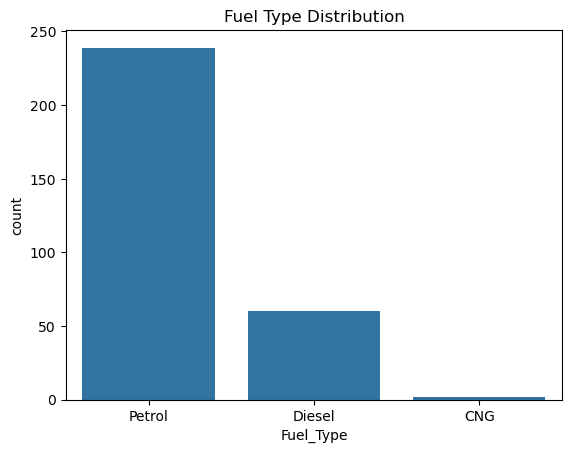

In [52]:
sns.countplot(x='Fuel_Type', data=df)

plt.title('Fuel Type Distribution')
plt.show()

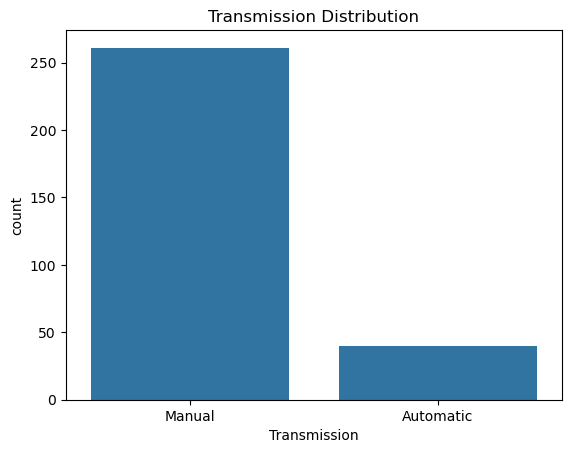

In [53]:
sns.countplot(x='Transmission', data=df)

plt.title('Transmission Distribution')
plt.show()

## Correlation Heatmap

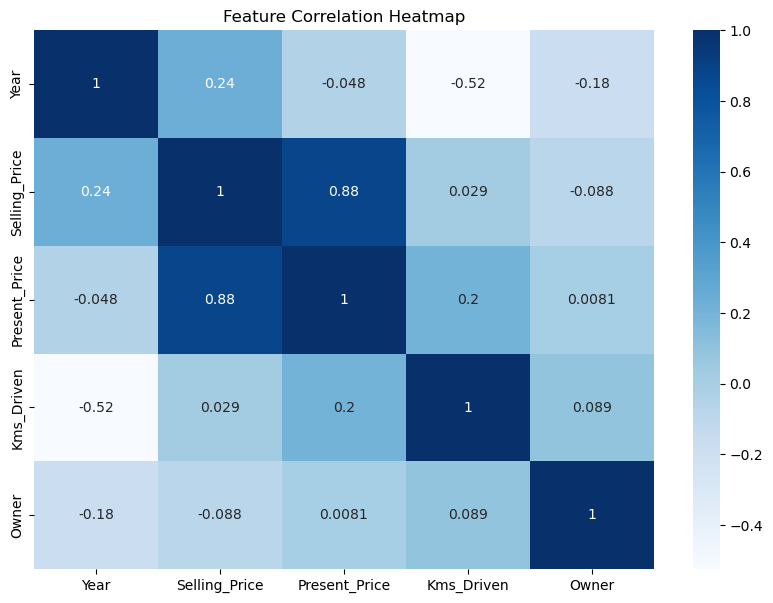

In [54]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title('Feature Correlation Heatmap')

plt.savefig('images/feature_correlation.png')
plt.show()

## Encoding Categorical Features

In [55]:
df.replace({
    'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2},
    'Seller_Type': {'Dealer': 0, 'Individual': 1},
    'Transmission': {'Manual': 0, 'Automatic': 1}
}, inplace=True)

df.head()

C:\Users\EgyTech\AppData\Local\Temp\ipykernel_6936\4211732674.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


## Splitting Features and Target Variable

In [56]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)
y = df['Selling_Price']

## Train-Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=2
)

# Linear Regression Model

In [58]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred_lin = lin_model.predict(X_test)

## Linear Regression Evaluation

In [60]:
r2_lin = r2_score(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)

print(f'Linear Regression R2 Score: {r2_lin:.2f}')
print(f'Linear Regression MSE: {mse_lin:.2f}')

Linear Regression R2 Score: 0.84
Linear Regression MSE: 2.15


## Actual vs Predicted Prices (Linear Regression)

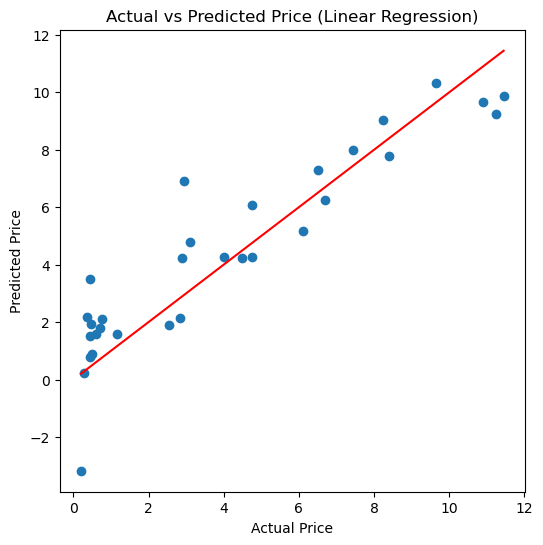

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lin)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price (Linear Regression)')
    
plt.savefig('images/linear_regression.png')
plt.show()

# Lasso Regression Model

In [62]:
las_model = Lasso()

las_model.fit(X_train, y_train)

Lasso()

In [63]:
y_pred_las = las_model.predict(X_test)

## Lasso Regression Evaluation

In [64]:
r2_las = r2_score(y_test, y_pred_las)

mse_las = mean_squared_error(y_test, y_pred_las)

print(f"R² Score: {r2_las:.2f}")

print(f"MSE: {mse_las:.2f}")

R² Score: 0.87
MSE: 1.70


## Actual vs Predicted Prices (Lasso Regression)

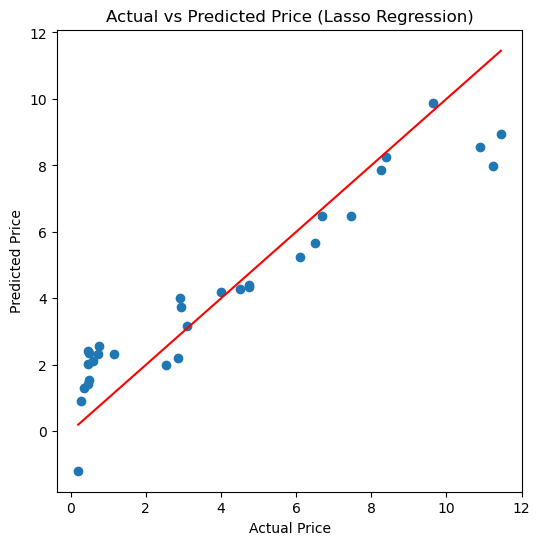

In [65]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_las)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price (Lasso Regression)')

plt.savefig('images/lasso_regression.png')
plt.show()

# Polynomial Regression Model

In [66]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [67]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [68]:
y_pred_poly = poly_model.predict(X_test_poly)

## Polynomial Regression Evaluation

In [69]:
r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f'Polynomial Regression R2 Score: {r2_poly:.2f}')
print(f'Polynomial Regression MSE: {mse_poly:.2f}')

Polynomial Regression R2 Score: 0.97
Polynomial Regression MSE: 0.35


## Actual vs Predicted Prices (Polynomial Regression)

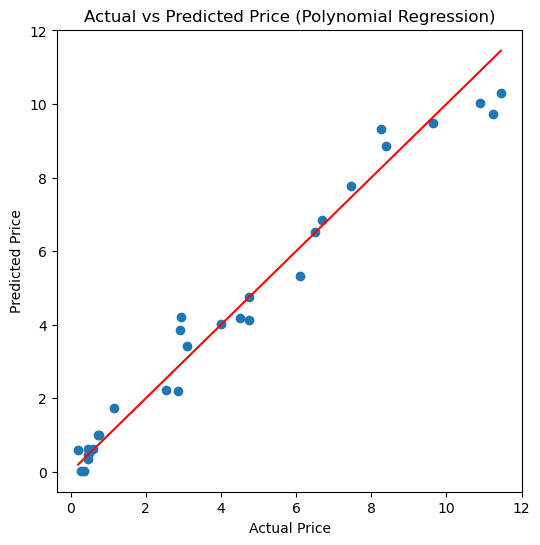

In [70]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_poly)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price (Polynomial Regression)')

plt.savefig('images/polynomial_regression.png')
plt.show()

# Ridge Regression Model

In [71]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [72]:
y_pred_ridge = ridge_model.predict(X_test)

In [73]:
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge Regression R² Score: {r2_ridge:.2f}")

print(f"Ridge Regression MSE: {mse_ridge:.2f}")

Ridge Regression R² Score: 0.84
Ridge Regression MSE: 2.10


## Ridge Regression Evaluation

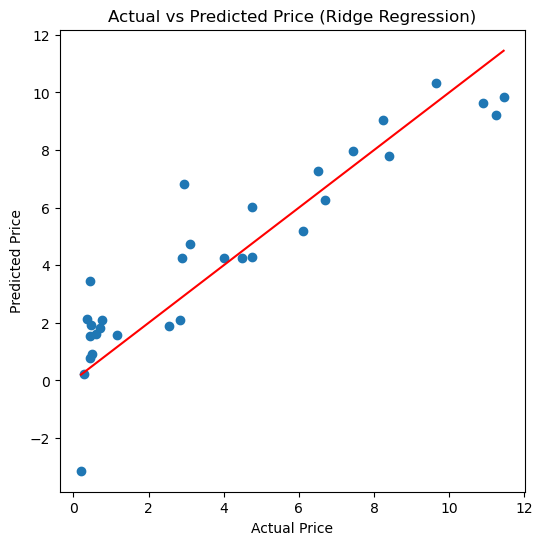

In [74]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_ridge)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price (Ridge Regression)')

plt.savefig('images/ridge_regression.png')
plt.show()

# Models Comparison

In [75]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Lasso Regression',
        'Polynomial Regression',
        'Ridge Regression'
    ],
    'R2 Score': [
        r2_lin,
        r2_las,
        r2_poly,
        r2_ridge
    ],
    'MSE': [
        mse_lin,
        mse_las,
        mse_poly,
        mse_ridge
    ]
})

results

,Model,R2 Score,MSE
0,Linear Regression,0.836577,2.150130
1,Lasso Regression,0.870917,1.698323
2,Polynomial Regression,0.973278,0.351573
3,Ridge Regression,0.840098,2.103806


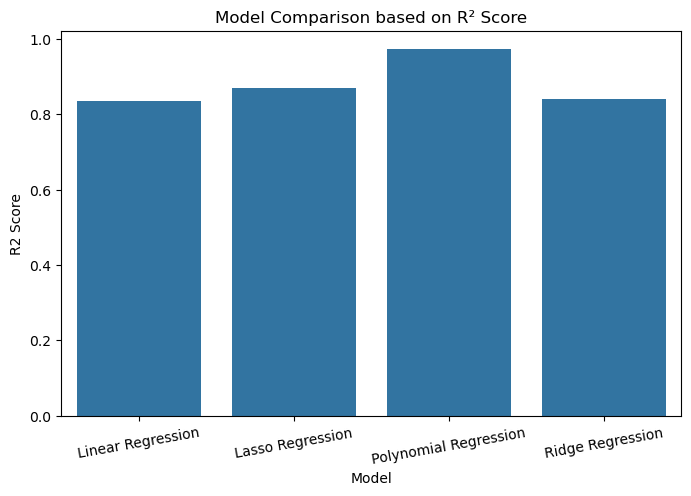

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title('Model Comparison based on R² Score')

plt.xticks(rotation=10)

plt.savefig('images/models_comparison.png')
plt.show()

# Conclusion

In this project, several Machine Learning regression models were implemented to predict car selling prices based on different car features.

The project included:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature encoding
- Model training and evaluation
- Data visualization

The following regression models were used and compared:
- Linear Regression
- Lasso Regression
- Polynomial Regression
- Ridge Regression

The models were evaluated using:
- R² Score
- Mean Squared Error (MSE)

Among all models, Polynomial Regression achieved the best performance because it was able to capture non-linear relationships within the dataset more effectively.

This project demonstrates a complete Machine Learning workflow, from data preparation to model comparison and performance evaluation.